In [ ]:
import pandas as pd

df = pd.read_csv('/content/Sales.csv')
df

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,10452,07-11-2022,Fries,3.49,573.07,Online,Gift Card,Tom Jackson,London
1,10453,07-11-2022,Beverages,2.95,745.76,Online,Gift Card,Pablo Perez,Madrid
2,10454,07-11-2022,Sides & Other,4.99,200.40,In-store,Gift Card,Joao Silva,Lisbon
3,10455,08-11-2022,Burgers,12.99,569.67,In-store,Credit Card,Walter Muller,Berlin
4,10456,08-11-2022,Chicken Sandwiches,9.95,201.01,In-store,Credit Card,Walter Muller,Berlin
...,...,...,...,...,...,...,...,...,...
249,10709,28-12-2022,Sides & Other,4.99,200.40,Drive-thru,Gift Card,Walter Muller,Berlin
250,10710,29-12-2022,Burgers,12.99,754.43,Drive-thru,Gift Card,Walter Muller,Berlin
251,10711,29-12-2022,Chicken Sandwiches,9.95,281.41,Drive-thru,Gift Card,Walter Muller,Berlin
252,10712,29-12-2022,Fries,3.49,630.37,Drive-thru,Gift Card,Walter Muller,Berlin


In [ ]:
import pandas as pd

df = pd.read_csv('/content/Sales.csv')

# Convert 'Date' column to datetime objects, coercing errors
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Display the first few rows of the DataFrame
print("Sample DataFrame:")
display(df.head())

# Display DataFrame info to check data types
print("\nDataFrame Info:")
df.info()

Sample DataFrame:


,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,10452,2022-11-07,Fries,3.49,573.07,Online,Gift Card,Tom Jackson,London
1,10453,2022-11-07,Beverages,2.95,745.76,Online,Gift Card,Pablo Perez,Madrid
2,10454,2022-11-07,Sides & Other,4.99,200.40,In-store,Gift Card,Joao Silva,Lisbon
3,10455,2022-11-08,Burgers,12.99,569.67,In-store,Credit Card,Walter Muller,Berlin
4,10456,2022-11-08,Chicken Sandwiches,9.95,201.01,In-store,Credit Card,Walter Muller,Berlin



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        254 non-null    int64         
 1   Date            254 non-null    datetime64[ns]
 2   Product         254 non-null    object        
 3   Price           254 non-null    float64       
 4   Quantity        254 non-null    float64       
 5   Purchase Type   254 non-null    object        
 6   Payment Method  254 non-null    object        
 7   Manager         254 non-null    object        
 8   City            254 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 18.0+ KB


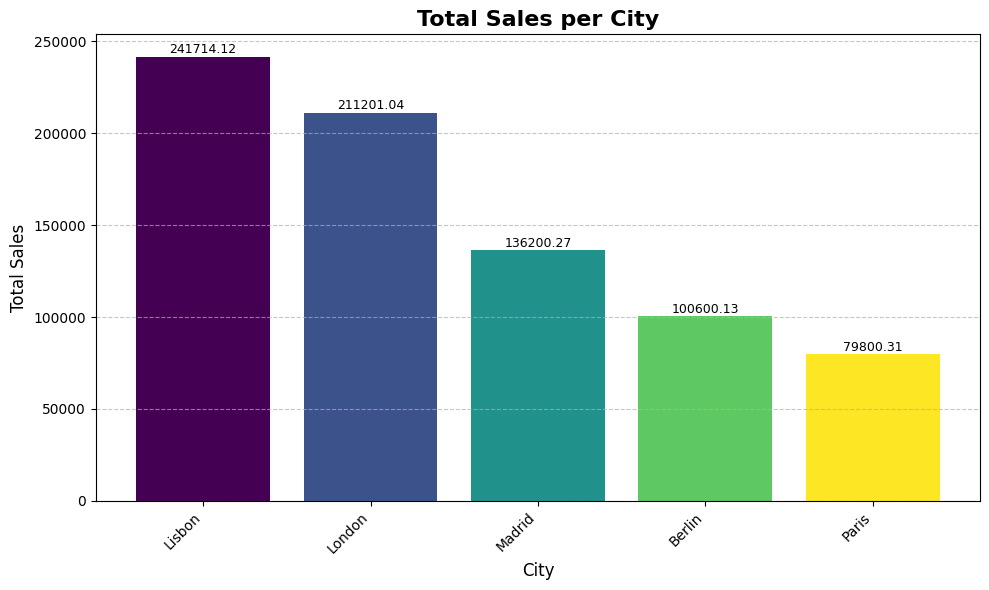

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Bar Chart Customization

# Calculate total sales (Price × Quantity) per City
df['Total Sales'] = df['Price'] * df['Quantity']

sales_per_city = df.groupby('City')['Total Sales'].sum().sort_values(ascending=False)

# Create the bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# Use different colors for each bar
colors = plt.cm.viridis(np.linspace(0, 1, len(sales_per_city)))
bars = ax.bar(sales_per_city.index, sales_per_city.values, color=colors)

# Add value labels above each bar
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 100, round(yval, 2), ha='center', va='bottom', fontsize=9)

# Rotate x-axis labels by 45° for readability
plt.xticks(rotation=45, ha='right')

# Add a grid only on the y-axis
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add titles and labels
plt.title('Total Sales per City', fontsize=16, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)

plt.tight_layout()
plt.show()

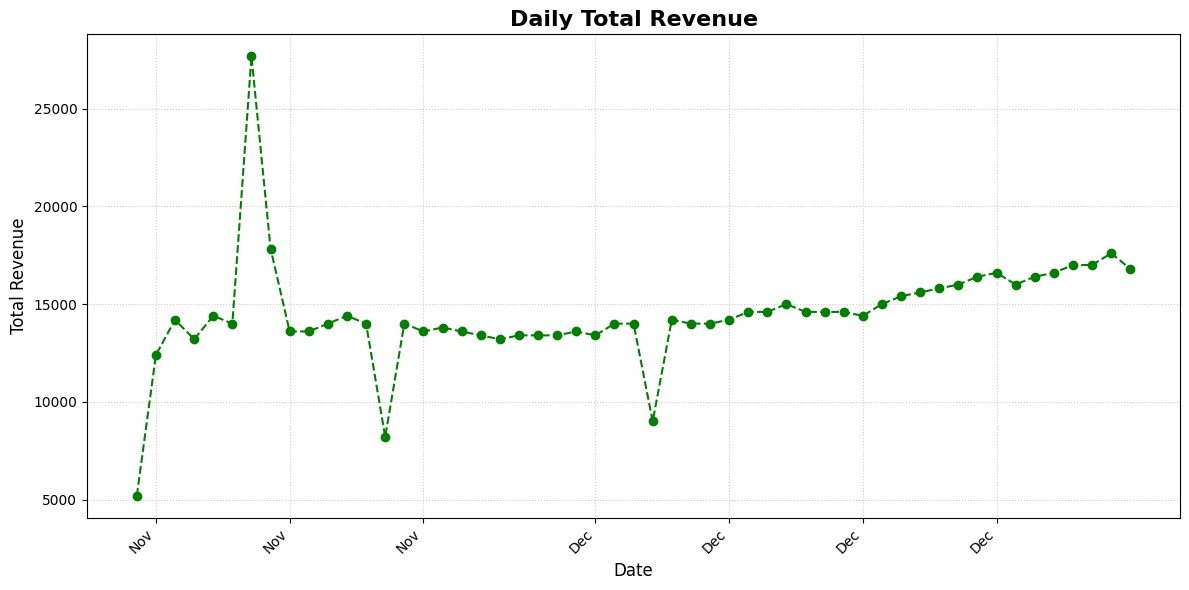

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 2. Line Chart with Styles

# Calculate daily total revenue (Price × Quantity)
# Ensure 'Date' column is in datetime format, handled during data loading
daily_revenue = df.groupby('Date')['Total Sales'].sum().reset_index()

# Create the line chart
fig, ax = plt.subplots(figsize=(12, 6))

# Plot with customizations:
# Dashed line ('--') with markers ('o')
# Change line color to green
ax.plot(daily_revenue['Date'], daily_revenue['Total Sales'], linestyle='--', marker='o', color='green')

# Add a title with bold font and larger size
plt.title('Daily Total Revenue', fontsize=16, fontweight='bold')

# Format x-axis ticks to show only month names
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b')) # %b for abbreviated month name
daily_revenue['Date'].dt.month_name()
plt.xticks(rotation=45, ha='right') # Rotate for readability if many dates
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

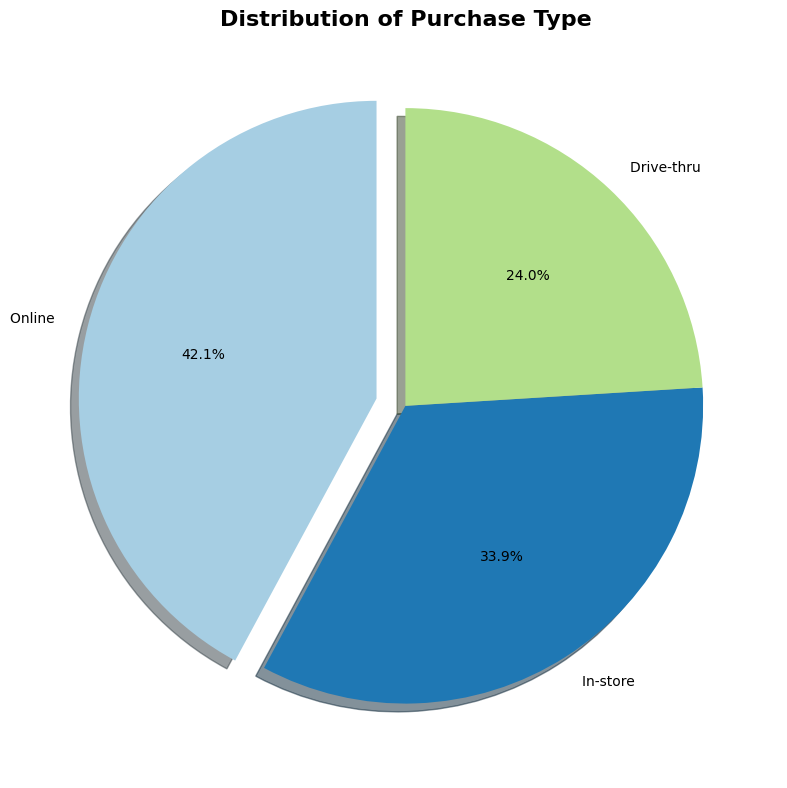

In [ ]:
import matplotlib.pyplot as plt

# 3. Pie Chart with Explode

purchase_type_counts = df['Purchase Type'].value_counts()

# Explode the largest slice
explode_val = (0.1,) + (0,) * (len(purchase_type_counts) - 1)

# Create the pie chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(purchase_type_counts,
                                  labels=purchase_type_counts.index,
                                  autopct='%1.1f%%',
                                  explode=explode_val,
                                  shadow=True,
                                  startangle=90,
                                  colors=plt.cm.Paired.colors)

# Customize percentage labels
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(10)

# Add a title
plt.title('Distribution of Purchase Type', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

<>:60: SyntaxWarning: invalid escape sequence '\$'
<>:60: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_167/3033511231.py:60: SyntaxWarning: invalid escape sequence '\$'
  ax.annotate(f"{row['Product']} (\${row['Price']:.2f})",



4. Stacked Bar Chart (Payment Method usage across Cities):


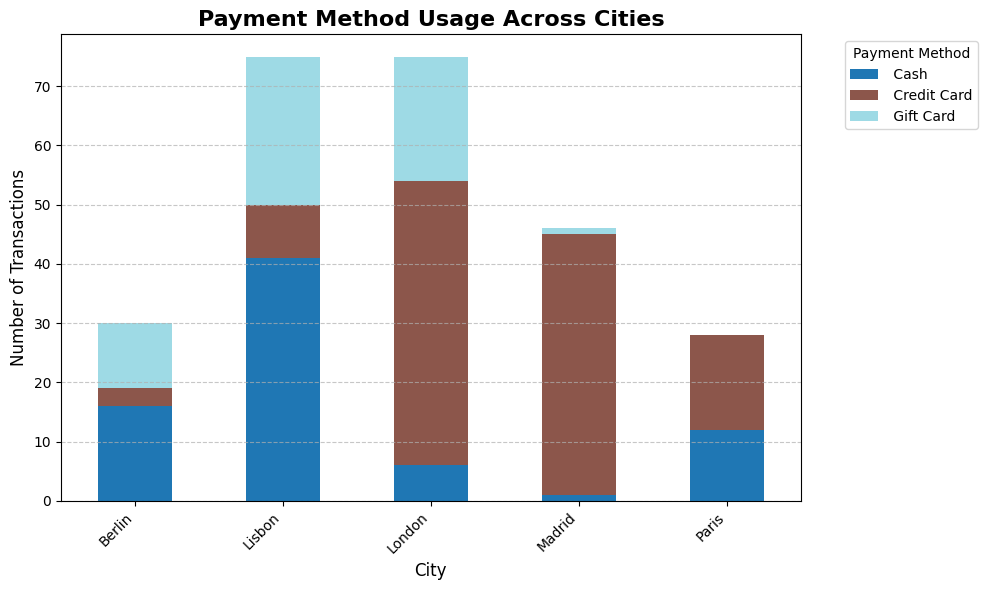


5. Scatter Plot (Price vs Quantity with Manager colors and top 3 annotations):


/tmp/ipykernel_167/3033511231.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Dark2', len(managers))


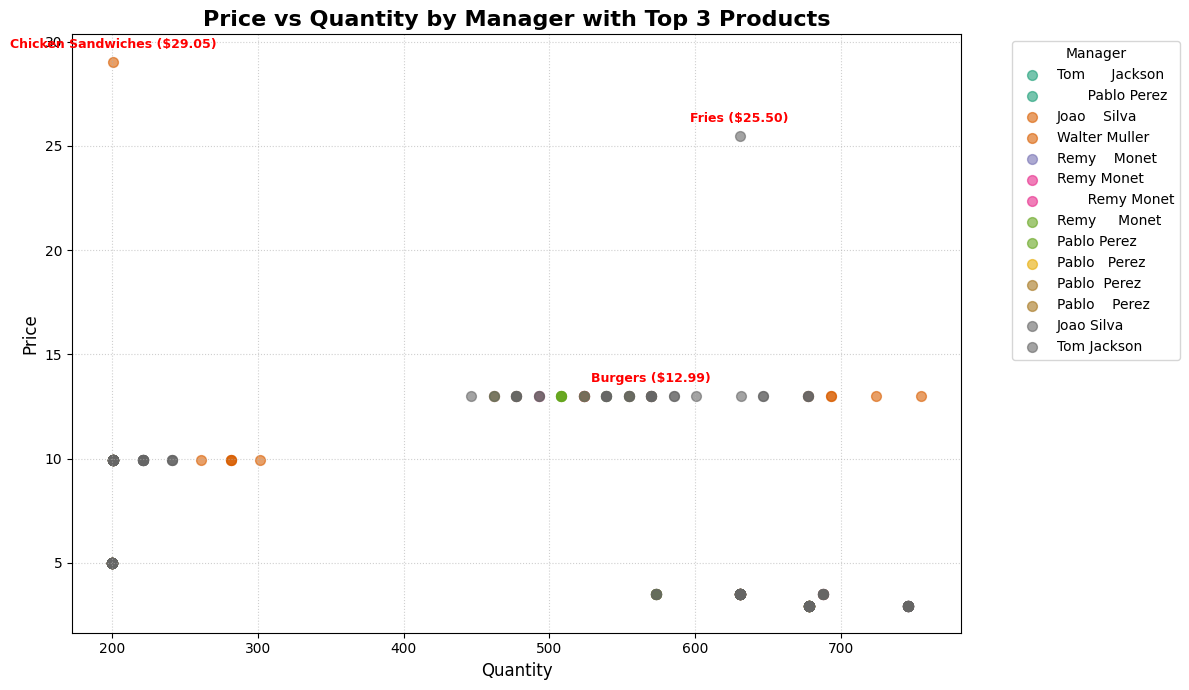


6. Advanced Customization Challenge (Multi-plot Figure):


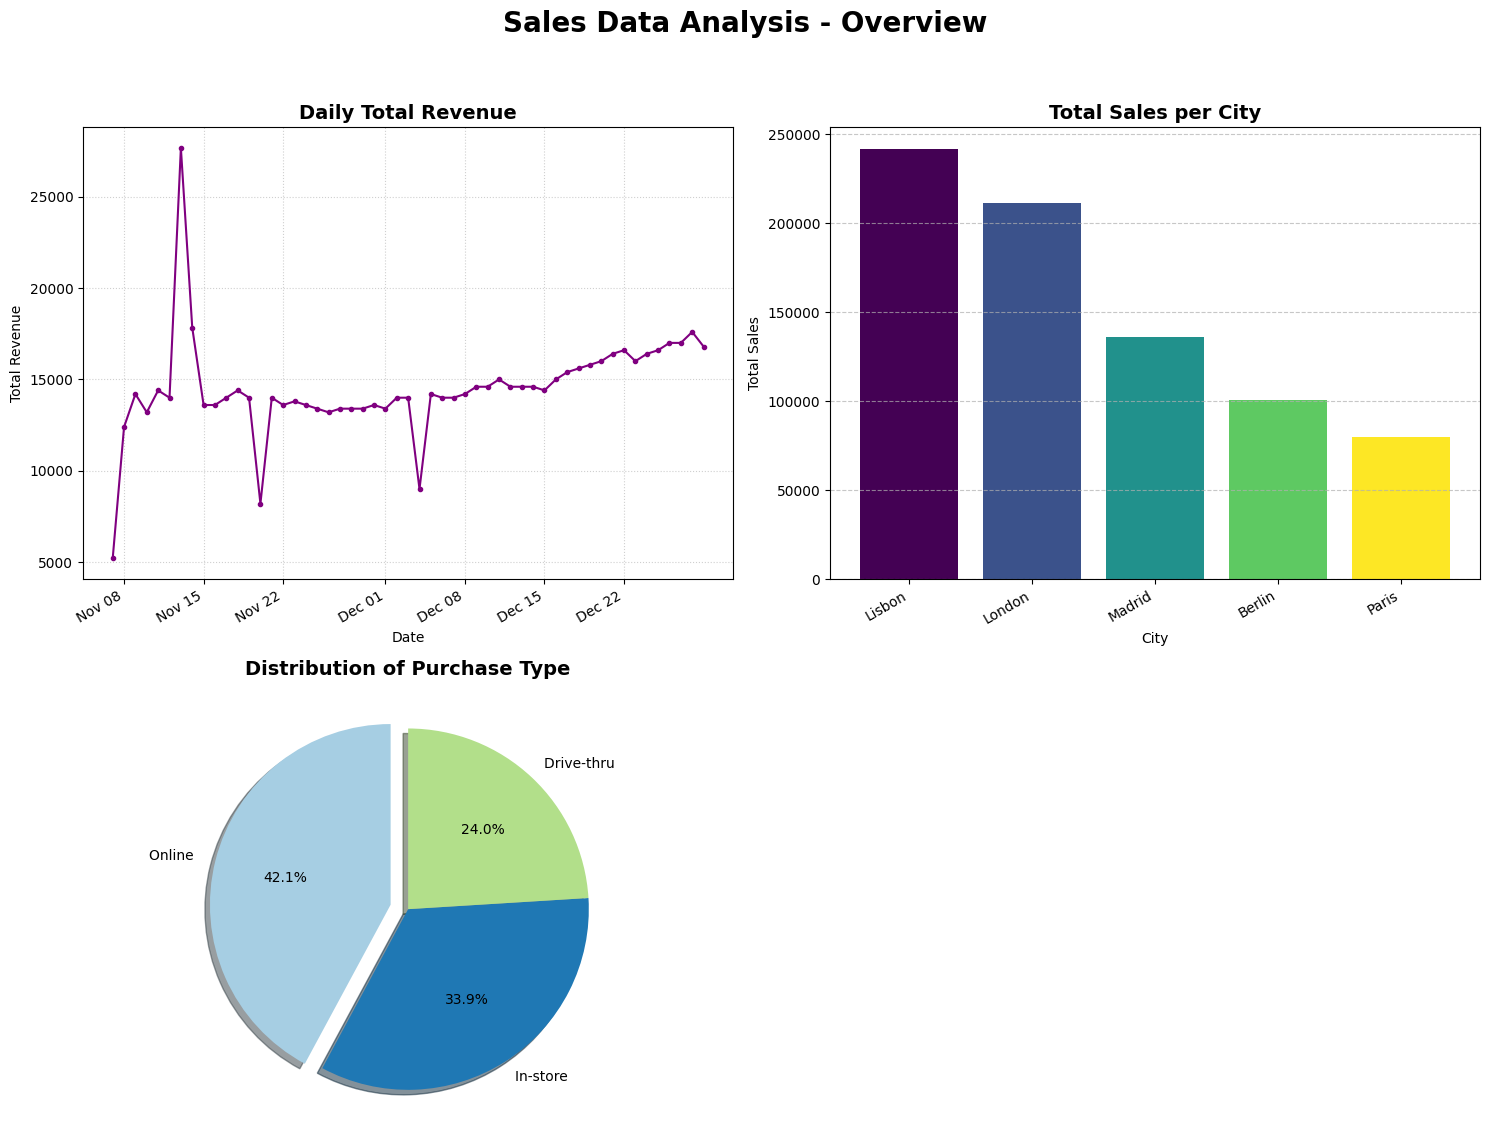

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.dates as mdates

# Ensure 'Total Sales' column exists for some plots if not already created
if 'Total Sales' not in df.columns:
    df['Total Sales'] = df['Price'] * df['Quantity']

# 4. Stacked Bar Chart
# Plot Payment Method usage across different Cities.
# Customize:
# - Use stacked bars with distinct colors.
# - Add a legend outside the plot.
# - Set figure size to (10,6).
# - Add horizontal grid lines.

print("\n4. Stacked Bar Chart (Payment Method usage across Cities):")
# Prepare data for stacked bar chart
pivot_table = df.groupby(['City', 'Payment Method']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))
pivot_table.plot(kind='bar', stacked=True, ax=ax, cmap='tab20')

plt.title('Payment Method Usage Across Cities', fontsize=16, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.legend(title='Payment Method', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# 5. Scatter Plot with Annotations
# - Plot Price vs Quantity for all products.
# - Customize:
# - Color points by Manager.
# - Add transparency (alpha=0.6).
# - Annotate the top 3 highest-priced products.
# - Add axis labels with custom font size.

print("\n5. Scatter Plot (Price vs Quantity with Manager colors and top 3 annotations):")
fig, ax = plt.subplots(figsize=(12, 7))

# Create a color map for managers
managers = df['Manager'].unique()
colors = plt.cm.get_cmap('Dark2', len(managers))
manager_color_map = {manager: colors(i) for i, manager in enumerate(managers)}

# Plot points, coloring by manager
for manager, color in manager_color_map.items():
    subset = df[df['Manager'] == manager]
    ax.scatter(subset['Quantity'], subset['Price'],
               label=manager, color=color, alpha=0.6, s=50)

# Annotate the top 3 highest-priced products
top_3_products = df.nlargest(3, 'Price')
for i, row in top_3_products.iterrows():
    ax.annotate(f"{row['Product']} (\${row['Price']:.2f})",
                (row['Quantity'], row['Price']),
                textcoords="offset points",
                xytext=(0, 10),
                ha='center', fontsize=9, color='red', fontweight='bold')

plt.title('Price vs Quantity by Manager with Top 3 Products', fontsize=16, fontweight='bold')
plt.xlabel('Quantity', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend(title='Manager', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


# 6. Advanced Customization Challenge
# - Create a multi-plot figure:
# - Top-left: Line chart of revenue over time.
# - Top-right: Bar chart of sales per city.
# - Bottom: Pie chart of purchase type.
# - Customize:
# - Use plt.subplots(2,2) layout.
# - Share y-axis where possible.
# - Add a super-title (fig.suptitle) with bold styling.
# - Adjust spacing using plt.tight_layout()

print("\n6. Advanced Customization Challenge (Multi-plot Figure):")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Sales Data Analysis - Overview', fontsize=20, fontweight='bold')

# Plot 1: Line chart of revenue over time (Top-left)
# Ensure 'Date' column is in datetime format and 'Total Sales' exists
daily_revenue = df.groupby('Date')['Total Sales'].sum().reset_index()
axes[0, 0].plot(daily_revenue['Date'], daily_revenue['Total Sales'], linestyle='-', marker='.', color='purple')
axes[0, 0].set_title('Daily Total Revenue', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Total Revenue')
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=30, ha='right')
axes[0, 0].grid(True, linestyle=':', alpha=0.6)

# Plot 2: Bar chart of sales per city (Top-right)
sales_per_city = df.groupby('City')['Total Sales'].sum().sort_values(ascending=False)
colors_bar = plt.cm.viridis(np.linspace(0, 1, len(sales_per_city)))
axes[0, 1].bar(sales_per_city.index, sales_per_city.values, color=colors_bar)
axes[0, 1].set_title('Total Sales per City', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('City')
axes[0, 1].set_ylabel('Total Sales')
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=30, ha='right')
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 3: Pie chart of purchase type (Bottom-left)
purchase_type_counts = df['Purchase Type'].value_counts()
explode_val_pie = (0.1,) + (0,) * (len(purchase_type_counts) - 1)
wedges, texts, autotexts = axes[1, 0].pie(purchase_type_counts,
                                          labels=purchase_type_counts.index,
                                          autopct='%1.1f%%',
                                          explode=explode_val_pie,
                                          shadow=True,
                                          startangle=90,
                                          colors=plt.cm.Paired.colors)
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(10)
axes[1, 0].set_title('Distribution of Purchase Type', fontsize=14, fontweight='bold')

# Hide the fourth subplot as it's not used
axes[1, 1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Assuming 'df' is already loaded from previous cells

# Prepare the data
# Select features (numerical columns)
X = df[['Price', 'Quantity']]

# Select target variable (categorical column)
y = df['Purchase Type']

# Encode the target variable if it's categorical (Logistic Regression requires numerical targets)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Initialize and train a Logistic Regression model
model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print("\nFirst 5 predictions vs actuals (encoded values):")
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(predictions_df.head())



Model Accuracy: 0.39

Classification Report:
              precision    recall  f1-score   support

 Drive-thru        0.00      0.00      0.00         8
   In-store        0.45      0.22      0.29        23
     Online        0.38      0.75      0.50        20

    accuracy                           0.39        51
   macro avg       0.28      0.32      0.26        51
weighted avg       0.35      0.39      0.33        51


First 5 predictions vs actuals (encoded values):
   Actual  Predicted
0       2          1
1       1          2
2       0          2
3       1          1
4       2          2


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Let's first understand the results of the **Logistic Regression Model**:

*   **Model Accuracy: 0.39**
    *   This means the model correctly predicted the `Purchase Type` for about 39% of the test samples. For a multi-class classification problem, this might indicate the model is not performing very well, perhaps struggling to distinguish between the different purchase types based solely on `Price` and `Quantity`.

*   **Classification Report:**
    *   **Precision:** For each class, precision tells you how many of the items predicted as belonging to that class actually belonged to it. For example, for 'In-store', when the model predicted an 'In-store' purchase, it was correct 45% of the time.
    *   **Recall:** For each class, recall tells you how many of the actual items of that class were correctly identified. For 'Online' purchases, the model correctly identified 75% of them.
    *   **F1-score:** This is the harmonic mean of precision and recall. It's a good metric to use when you have an uneven class distribution.
    *   **Support:** This is the number of actual occurrences of the class in the specified dataset (here, the test set). For example, there were 8 'Drive-thru' purchases in the test set.
    *   **`Drive-thru` has `0.00` precision and recall**: This indicates the model completely failed to predict any 'Drive-thru' purchases correctly. This could be due to a class imbalance (only 8 samples) or because its features (`Price`, `Quantity`) are very similar to other classes.
    *   **`macro avg`**: The average performance across all classes, treating all classes equally.
    *   **`weighted avg`**: The average performance across all classes, weighted by the number of samples in each class.

**Why the low accuracy?**

1.  **Limited Features**: We only used `Price` and `Quantity`. Other features like `Product`, `Date`, `City`, or `Manager` might be more influential in determining the `Purchase Type`.
2.  **Class Imbalance**: The number of samples for each `Purchase Type` in the test set is imbalanced (`Drive-thru`: 8, `In-store`: 23, `Online`: 20). Models can struggle with minority classes.
3.  **Model Simplicity**: Logistic Regression is a linear model. The relationship between `Price`, `Quantity`, and `Purchase Type` might be non-linear.

### Exploring Another Algorithm: Decision Tree Classifier

Now, let's try a different classification algorithm: the **Decision Tree Classifier**. Decision Trees are non-linear models that can capture more complex relationships in the data. They work by creating a tree-like model of decisions, where each internal node represents a 'test' on an attribute, each branch represents the outcome of the test, and each leaf node represents a class label (decision).

We'll use the same `X` (features: Price, Quantity) and `y_encoded` (target: Purchase Type) data for consistency.


Decision Tree Model Accuracy: 0.49

Decision Tree Classification Report:
              precision    recall  f1-score   support

 Drive-thru        0.75      0.38      0.50         8
   In-store        0.62      0.22      0.32        23
     Online        0.44      0.85      0.58        20

    accuracy                           0.49        51
   macro avg       0.60      0.48      0.47        51
weighted avg       0.57      0.49      0.45        51


Decision Tree Confusion Matrix:


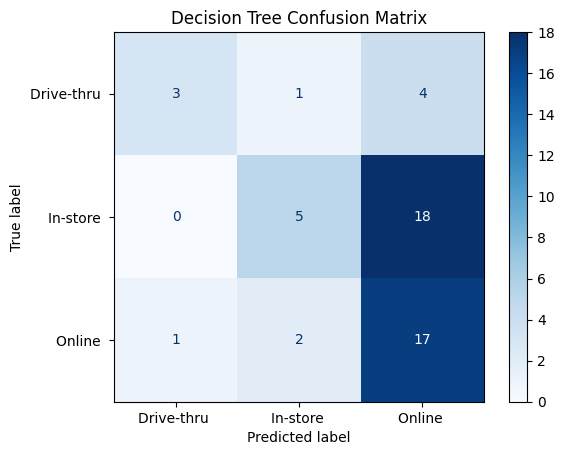

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize a Decision Tree Classifier
dtree_model = DecisionTreeClassifier(random_state=42)

# Train the model on the training data
dtree_model.fit(X_train, y_train)

# Make predictions on the test set
dtree_pred = dtree_model.predict(X_test)

# Evaluate the Decision Tree model
dtree_accuracy = accuracy_score(y_test, dtree_pred)
print(f"\nDecision Tree Model Accuracy: {dtree_accuracy:.2f}")

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, dtree_pred, target_names=label_encoder.classes_))

# Visualize the Confusion Matrix for Decision Tree
print("\nDecision Tree Confusion Matrix:")
cm = confusion_matrix(y_test, dtree_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Decision Tree Confusion Matrix')
plt.show()


### Other Algorithms You Could Explore:

*   **Random Forest Classifier**: An ensemble learning method that builds multiple decision trees and merges their results to improve accuracy and control overfitting.
*   **Support Vector Machine (SVM)**: A powerful model that finds the optimal hyperplane to separate classes in a high-dimensional space.
*   **K-Nearest Neighbors (KNN)**: A simple, non-parametric algorithm that classifies a data point based on the majority class of its 'k' nearest neighbors in the feature space.
*   **Gradient Boosting (e.g., XGBoost, LightGBM)**: Highly powerful and widely used ensemble methods that build trees sequentially, with each new tree trying to correct errors made by previous ones.

### Visualizing Model Comparisons:

To effectively compare multiple models, you can:

1.  **Compare Accuracy/F1-scores**: Create a bar chart showing the accuracy or F1-score of each model.
2.  **Confusion Matrices**: Display confusion matrices for each model to see how each class is being predicted (true positives, false positives, true negatives, false negatives).
3.  **ROC Curves (for Binary Classification)**: If you were doing binary classification, ROC (Receiver Operating Characteristic) curves and AUC (Area Under the Curve) are great for comparing the trade-off between true positive rate and false positive rate.
4.  **Feature Importance**: For tree-based models, you can visualize which features were most important in making predictions.